In [8]:
!pip install tensorflow

In [9]:
# Import required libraries
import numpy as np
import pickle
import os
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Concatenate
from tensorflow.keras.utils import to_categorical

In [10]:
# List of participants in the WESAD dataset
participants = ['S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17']


In [11]:
# Initialize empty lists to store data from all participants
all_ecg_data, all_eda_data, all_acc_data, all_labels = [], [], [], []

In [12]:
# Iterate over all participants and load their data
for participant in participants:
    # Load each participant's data
    with open(fr'D:\LSTM Project\WESAD\{participant}\{participant}.pkl', 'rb') as f:
        data = pickle.load(f, encoding='latin1')

    # Extract relevant signals (ECG, EDA, ACC) and labels
    chest_data = data['signal']['chest']
    labels = data['label']

    # Append to the lists (concatenate data across participants)
    all_ecg_data.append(chest_data['ECG'])
    all_eda_data.append(chest_data['EDA'])
    all_acc_data.append(chest_data['ACC'])
    all_labels.append(labels)

In [13]:
# Concatenate data from all participants into single arrays
all_ecg_data = np.concatenate(all_ecg_data, axis=0)
all_eda_data = np.concatenate(all_eda_data, axis=0)
all_acc_data = np.concatenate(all_acc_data, axis=0)
all_labels = np.concatenate(all_labels, axis=0)


In [14]:
# Check the shapes of the combined data
print(all_ecg_data.shape, all_eda_data.shape, all_acc_data.shape, all_labels.shape)


(60807600, 1) (60807600, 1) (60807600, 3) (60807600,)


In [15]:
# Initialize the MinMaxScaler
scaler = MinMaxScaler()

In [16]:
# Normalize each modality
ecg_data_normalized = scaler.fit_transform(all_ecg_data)
eda_data_normalized = scaler.fit_transform(all_eda_data)
acc_data_normalized = scaler.fit_transform(all_acc_data.reshape(-1, all_acc_data.shape[1]))

In [17]:
# Reshape accelerometer data back to 3D shape (if needed)
acc_data_normalized = acc_data_normalized.reshape(all_acc_data.shape)

In [18]:
# Function to create sliding windows
def create_windows(data, labels, window_size, step_size):
    X, y = [], []
    for i in range(0, len(data) - window_size, step_size):
        X.append(data[i:i+window_size].astype(np.float32))  # convert to float32
        y.append(np.bincount(labels[i:i+window_size]).argmax())  # most common label
    return np.array(X, dtype=np.float32), np.array(y)

# Optional: downsample data to reduce memory (e.g., by half)
def downsample(data, factor=2):
    return data[::factor]

# Downsample all data
all_ecg_data = downsample(all_ecg_data)
all_eda_data = downsample(all_eda_data)
all_acc_data = downsample(all_acc_data)
all_labels = downsample(all_labels)

# Normalize again after downsampling
ecg_data_normalized = scaler.fit_transform(all_ecg_data).astype(np.float32)
eda_data_normalized = scaler.fit_transform(all_eda_data).astype(np.float32)
acc_data_normalized = scaler.fit_transform(all_acc_data.reshape(-1, all_acc_data.shape[1])).astype(np.float32)
acc_data_normalized = acc_data_normalized.reshape(all_acc_data.shape).astype(np.float32)

# Sliding window parameters
window_size = 100
step_size = 50

# Create windows
X_ecg, y = create_windows(ecg_data_normalized, all_labels, window_size, step_size)
X_eda, _ = create_windows(eda_data_normalized, all_labels, window_size, step_size)
X_acc, _ = create_windows(acc_data_normalized, all_labels, window_size, step_size)

# Convert labels to categorical
y = to_categorical(y)

# Check the shape of the data
print(X_ecg.shape, X_eda.shape, X_acc.shape, y.shape)

(608074, 100, 1) (608074, 100, 1) (608074, 100, 3) (608074, 8)


In [19]:
import os

# Define a directory to save the files
save_dir = 'D:\LSTM Project\Dir'

# Ensure the directory exists
os.makedirs(save_dir, exist_ok=True)

# Split the data into train and test sets
X_train_ecg, X_test_ecg, X_train_eda, X_test_eda, X_train_acc, X_test_acc, y_train, y_test = train_test_split(
    X_ecg, X_eda, X_acc, y, test_size=0.2, random_state=42
)

# Save the split data with full file paths
np.save(os.path.join(save_dir, 'X_train_ecg.npy'), X_train_ecg)
np.save(os.path.join(save_dir, 'X_train_eda.npy'), X_train_eda)
np.save(os.path.join(save_dir, 'X_train_acc.npy'), X_train_acc)
np.save(os.path.join(save_dir, 'y_train.npy'), y_train)
np.save(os.path.join(save_dir, 'X_test_ecg.npy'), X_test_ecg)
np.save(os.path.join(save_dir, 'X_test_eda.npy'), X_test_eda)
np.save(os.path.join(save_dir, 'X_test_acc.npy'), X_test_acc)
np.save(os.path.join(save_dir, 'y_test.npy'), y_test)


In [20]:
# from tensorflow.keras.utils import Sequence
# import numpy as np

# # Define data generator
# class MultiModalDataGenerator(Sequence):
#     def __init__(self, ecg_path, eda_path, acc_path, y_path, batch_size):
#         # Load data with memory-mapping to handle large datasets efficiently
#         self.X_ecg = np.load(ecg_path, mmap_mode='r')
#         self.X_eda = np.load(eda_path, mmap_mode='r')
#         self.X_acc = np.load(acc_path, mmap_mode='r')
#         self.y = np.load(y_path, mmap_mode='r')
#         self.batch_size = batch_size
#         self.indices = np.arange(len(self.y))

#     def __len__(self):
#         # Calculate the number of batches per epoch
#         return int(np.ceil(len(self.y) / self.batch_size))

#     def __getitem__(self, idx):
#         # Get the indices for the current batch
#         batch_indices = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
#         # Return the corresponding data and labels
#         return [self.X_ecg[batch_indices], self.X_eda[batch_indices], self.X_acc[batch_indices]], self.y[batch_indices]
    
#     def on_epoch_end(self):
#         # Shuffle indices at the end of each epoch to prevent the model from learning any patterns from data order
#         np.random.shuffle(self.indices)
import numpy as np
from tensorflow.keras.utils import Sequence

class MultiModalDataGenerator(Sequence):
    def __init__(self, ecg_path, eda_path, acc_path, y_path, batch_size):
        # Load data with memory mapping to handle large datasets efficiently
        self.X_ecg = np.load(ecg_path, mmap_mode='r')
        self.X_eda = np.load(eda_path, mmap_mode='r')
        self.X_acc = np.load(acc_path, mmap_mode='r')
        self.y = np.load(y_path, mmap_mode='r')

        self.batch_size = batch_size
        self.indices = np.arange(len(self.y))

    def __len__(self):
        # Number of batches per epoch
        return int(np.ceil(len(self.y) / self.batch_size))

    def __getitem__(self, idx):
        # Get the indices for this batch
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]

        # Load the batch data
        batch_ecg = self.X_ecg[batch_idx]
        batch_eda = self.X_eda[batch_idx]
        batch_acc = self.X_acc[batch_idx]
        batch_y = self.y[batch_idx]

        # Return input and output
        return (batch_ecg, batch_eda, batch_acc), batch_y

    def on_epoch_end(self):
        # Shuffle indices after each epoch if needed
        np.random.shuffle(self.indices)



In [21]:
# Create generators
batch_size = 64
train_gen = MultiModalDataGenerator('X_train_ecg.npy', 'X_train_eda.npy', 'X_train_acc.npy', 'y_train.npy', batch_size)
test_gen = MultiModalDataGenerator('X_test_ecg.npy', 'X_test_eda.npy', 'X_test_acc.npy', 'y_test.npy', batch_size)

In [22]:
# Check shapes after the split
print(X_train_ecg.shape, X_test_ecg.shape, y_train.shape, y_test.shape)

(486459, 100, 1) (121615, 100, 1) (486459, 8) (121615, 8)


In [23]:
# Define LSTM inputs for each modality
ecg_input = Input(shape=(window_size, 1))  # ECG input
eda_input = Input(shape=(window_size, 1))  # EDA input
acc_input = Input(shape=(window_size, 3))  # Accelerometer input

# Define LSTM layers for each modality
ecg_lstm = LSTM(units=64)(ecg_input)
eda_lstm = LSTM(units=64)(eda_input)
acc_lstm = LSTM(units=64)(acc_input)

# Concatenate the LSTM outputs
merged = Concatenate()([ecg_lstm, eda_lstm, acc_lstm])

# Add dense layers and output
dense = Dense(32, activation='relu')(merged)
output = Dense(y_train.shape[1], activation='softmax')(dense)

# Build the model
model = Model(inputs=[ecg_input, eda_input, acc_input], outputs=output)

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 100, 1)            │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer_1 (InputLayer)    │ (None, 100, 1)            │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer_2 (InputLayer)    │ (None, 100, 3)            │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm (LSTM)                   │ (None, 64)                │          16,896 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_1 (LSTM)                 │ (None, 64)                │          16,896 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_2 (LSTM)                 │ (None, 64)                │          17,408 │ input_layer_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 192)               │               0 │ lstm[0][0], lstm_1[0][0],  │
│                               │                           │                 │ lstm_2[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 32)                │           6,176 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 8)                 │             264 │ dense[0][0]                │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 57,640 (225.16 KB)

 Trainable params: 57,640 (225.16 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Instantiate the data generators for training and validation
train_gen = MultiModalDataGenerator(
    ecg_path="D:\LSTM Project\Dir\X_train_ecg.npy",
    eda_path="D:\LSTM Project\Dir\X_train_eda.npy",
    acc_path="D:\LSTM Project\Dir\X_train_acc.npy",
    y_path="D:\LSTM Project\Dir\y_train.npy",
    batch_size=32
)

test_gen = MultiModalDataGenerator(
    ecg_path="D:\LSTM Project\Dir\X_test_ecg.npy",
    eda_path="D:\LSTM Project\Dir\X_test_eda.npy",
    acc_path="D:\LSTM Project\Dir\X_test_acc.npy",
    y_path="D:\LSTM Project\Dir\y_test.npy",
    batch_size=32
)

# Train the model
history = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=10
)
# Predict
y_pred = model.predict(test_gen)
y_test = np.load("D:\LSTM Project\Dir\y_test.npy", mmap_mode='r')

# Convert predictions and true values back to class labels
y_pred_labels = np.argmax(y_pred, axis=1)
y_test_labels = np.argmax(y_test, axis=1)
model.save("D:/LSTM Project/my_model.h5")

Epoch 1/10
15202/15202 ━━━━━━━━━━━━━━━━━━━━ 1096s 72ms/step - accuracy: 0.5008 - loss: 1.2586 - val_accuracy: 0.5753 - val_loss: 1.0537
Epoch 2/10
15202/15202 ━━━━━━━━━━━━━━━━━━━━ 1157s 76ms/step - accuracy: 0.6017 - loss: 1.0047 - val_accuracy: 0.6813 - val_loss: 0.8275
Epoch 3/10
15202/15202 ━━━━━━━━━━━━━━━━━━━━ 1017s 67ms/step - accuracy: 0.6621 - loss: 0.8622 - val_accuracy: 0.7209 - val_loss: 0.7167
Epoch 4/10
15202/15202 ━━━━━━━━━━━━━━━━━━━━ 1022s 67ms/step - accuracy: 0.6999 - loss: 0.7837 - val_accuracy: 0.7438 - val_loss: 0.6773
Epoch 5/10
15202/15202 ━━━━━━━━━━━━━━━━━━━━ 1011s 66ms/step - accuracy: 0.7590 - loss: 0.6342 - val_accuracy: 0.8102 - val_loss: 0.5147
Epoch 6/10
15202/15202 ━━━━━━━━━━━━━━━━━━━━ 1007s 66ms/step - accuracy: 0.7924 - loss: 0.5480 - val_accuracy: 0.8044 - val_loss: 0.5164
Epoch 7/10
15202/15202 ━━━━━━━━━━━━━━━━━━━━ 1042s 69ms/step - accuracy: 0.7988 - loss: 0.5282 - val_accuracy: 0.8146 - val_loss: 0.4899
Epoch 8/10
15202/15202 ━━━━━━━━━━━━━━━━━━━━ 991s

In [26]:
# Predict
y_pred = model.predict(test_gen)
y_test = np.load("D:\LSTM Project\Dir\y_test.npy", mmap_mode='r')

# Convert predictions and true values back to class labels
y_pred_labels = np.argmax(y_pred, axis=1)
y_test_labels = np.argmax(y_test, axis=1)

3801/3801 ━━━━━━━━━━━━━━━━━━━━ 61s 16ms/step


In [9]:
# Import required libraries
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. First load your test data
X_test_ecg = np.load('D:\\LSTM Project\\Dir\\X_test_ecg.npy')
X_test_eda = np.load('D:\\LSTM Project\\Dir\\X_test_eda.npy')
X_test_acc = np.load('D:\\LSTM Project\\Dir\\X_test_acc.npy')
y_test = np.load('D:\\LSTM Project\\y_test.npy')

# 2. Recreate your test generator (same as during training)
class MultiModalDataGenerator:
    def __init__(self, ecg_data, eda_data, acc_data, labels, batch_size=32):
        self.X_ecg = ecg_data
        self.X_eda = eda_data
        self.X_acc = acc_data
        self.y = labels
        self.batch_size = batch_size
        self.indices = np.arange(len(self.y))
        
    def __len__(self):
        return int(np.ceil(len(self.y) / self.batch_size))
    
    def __getitem__(self, idx):
        batch_indices = self.indices[idx*self.batch_size:(idx+1)*self.batch_size]
        return (
            [self.X_ecg[batch_indices], self.X_eda[batch_indices], self.X_acc[batch_indices]],
            self.y[batch_indices]
        )

# 3. Create the test generator
test_gen = MultiModalDataGenerator(X_test_ecg, X_test_eda, X_test_acc, y_test, batch_size=32)

# 4. Generate predictions
y_pred = []
for i in range(len(test_gen)):
    x_batch, _ = test_gen[i]
    batch_pred = model.predict(x_batch, verbose=0)
    y_pred.extend(batch_pred)
y_pred = np.array(y_pred)

# 5. Convert to class labels
y_pred_labels = np.argmax(y_pred, axis=1) if len(y_pred.shape) > 1 else y_pred.astype(int)
y_test_labels = np.argmax(y_test, axis=1) if len(y_test.shape) > 1 else y_test.astype(int)

# 6. Verify shapes
print(f"Predicted samples: {len(y_pred_labels)}")
print(f"True samples: {len(y_test_labels)}")

# 7. Calculate metrics
accuracy = accuracy_score(y_test_labels, y_pred_labels)
f1 = f1_score(y_test_labels, y_pred_labels, average='weighted')
precision = precision_score(y_test_labels, y_pred_labels, average='weighted')
recall = recall_score(y_test_labels, y_pred_labels, average='weighted')

# 8. Print results
print("\n" + "="*50)
print("MODEL EVALUATION RESULTS".center(50))
print("="*50)
print(f"{'Accuracy:':<12} {accuracy:.4f}")
print(f"{'F1 Score:':<12} {f1:.4f}")
print(f"{'Precision:':<12} {precision:.4f}")
print(f"{'Recall:':<12} {recall:.4f}")
print("="*50 + "\n")


Predicted samples: 121615
True samples: 121615

             MODEL EVALUATION RESULTS             
Accuracy:    0.7898
F1 Score:    0.7827
Precision:   0.7799
Recall:      0.7898




Binary Classification Report (Stress vs Non-Stress):
              precision    recall  f1-score   support

  Non-Stress       0.96      0.96      0.96     97166
      Stress       0.86      0.86      0.86     24449

    accuracy                           0.94    121615
   macro avg       0.91      0.91      0.91    121615
weighted avg       0.94      0.94      0.94    121615



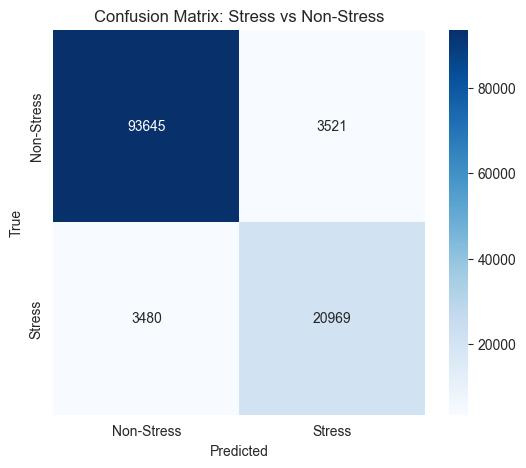

In [19]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Convert one-hot to label indices if needed
# y_test_labels = np.argmax(y_test, axis=1)
# y_pred_labels = np.argmax(y_pred, axis=1)

# Step 1: Define stress class label(s) – assuming stress is labeled as 1
stress_class_label = 1

# Step 2: Map to binary labels
y_test_binary = np.where(y_test_labels == stress_class_label, 1, 0)
y_pred_binary = np.where(y_pred_labels == stress_class_label, 1, 0)

# Step 3: Class names
class_names = ['Non-Stress', 'Stress']

# Step 4: Generate classification report
print("\nBinary Classification Report (Stress vs Non-Stress):")
print(classification_report(y_test_binary, y_pred_binary, target_names=class_names))

# Step 5: Confusion matrix
cm = confusion_matrix(y_test_binary, y_pred_binary)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix: Stress vs Non-Stress')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


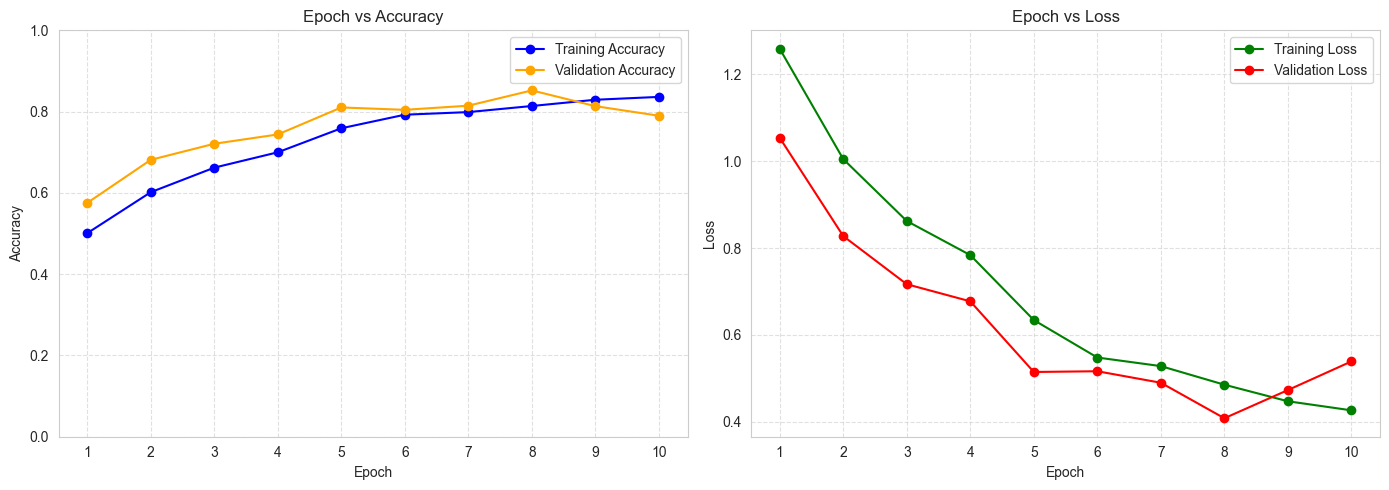

In [18]:
import matplotlib.pyplot as plt

# Data from your logs
epochs = list(range(1, 11))

# Accuracy
train_accuracy = [0.5008, 0.6017, 0.6621, 0.6999, 0.7590, 0.7924, 0.7988, 0.8138, 0.8292, 0.8362]
val_accuracy = [0.5753, 0.6813, 0.7209, 0.7438, 0.8102, 0.8044, 0.8146, 0.8522, 0.8134, 0.7898]

# Loss
train_loss = [1.2586, 1.0047, 0.8622, 0.7837, 0.6342, 0.5480, 0.5282, 0.4854, 0.4473, 0.4264]
val_loss = [1.0537, 0.8275, 0.7167, 0.6773, 0.5147, 0.5164, 0.4899, 0.4082, 0.4731, 0.5390]

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Plot Accuracy
axs[0].plot(epochs, train_accuracy, marker='o', label='Training Accuracy', color='blue')
axs[0].plot(epochs, val_accuracy, marker='o', label='Validation Accuracy', color='orange')
axs[0].set_title("Epoch vs Accuracy")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Accuracy")
axs[0].set_xticks(epochs)
axs[0].set_ylim(0, 1)
axs[0].legend()
axs[0].grid(True, linestyle='--', alpha=0.6)

# Plot Loss
axs[1].plot(epochs, train_loss, marker='o', label='Training Loss', color='green')
axs[1].plot(epochs, val_loss, marker='o', label='Validation Loss', color='red')
axs[1].set_title("Epoch vs Loss")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Loss")
axs[1].set_xticks(epochs)
axs[1].legend()
axs[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()
